In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [4]:
df['Дата'] = pd.to_datetime(df['Дата'], format='%Y-%m-%d')

Сгруппируйте данные по дате, посчитайте количество продаж

In [5]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

Вывести несколько первых строк сгруппированных данных

In [6]:
print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Нарисуйте график продаж у `grouped_df`

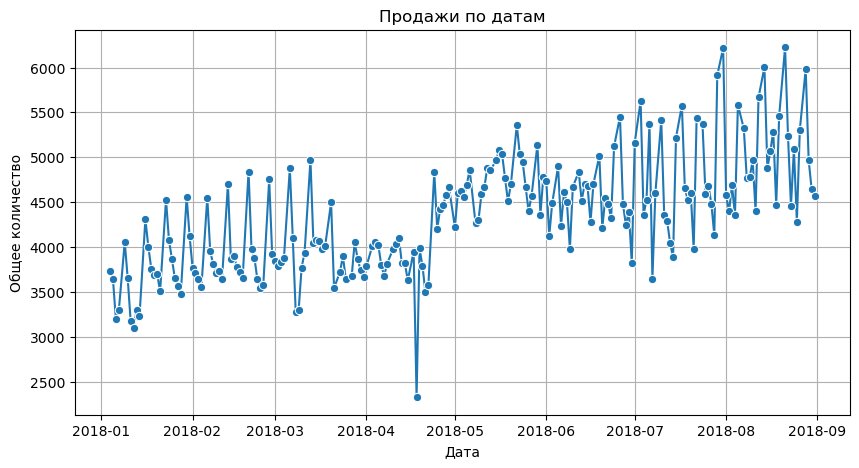

In [7]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=grouped_df, x='Дата', y='Количество', marker='o')
plt.title('Продажи по датам')
plt.xlabel('Дата')
plt.ylabel('Общее количество')
plt.grid(True)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [8]:
max_row = df[df['Количество'] == df['Количество'].max()]
print(max_row)

             Дата  Склад   Контрагент Номенклатура  Количество
218822 2018-06-28      1  address_208    product_0         200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [9]:
df_filtered = df[
    (df['Склад'] == 3) &
    (df['Дата'].dt.month.isin([6, 7, 8])) &
    (df['Дата'].dt.dayofweek == 2)
]

top_product = df_filtered.groupby('Номенклатура')['Количество'].sum().sort_values(ascending=False).head(1)
print(top_product)

Номенклатура
product_1    2267
Name: Количество, dtype: int64


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [10]:
df_weather = pd.read_csv(
    'weather.csv',
    skiprows=6,
    delimiter=';',
    encoding='utf-8',
    on_bad_lines='skip'
)[['Местное время в Астане', 'T']]

df_weather.columns = ['Дата', 'Температура']

df_weather['Дата'] = pd.to_datetime(df_weather['Дата'], format='%d.%m.%Y %H:%M', errors='coerce')
df_weather['Температура'] = (
    df_weather['Температура']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

df_weather = df_weather.dropna(subset=['Дата', 'Температура'])

grouped_df = (
    df_weather
    .groupby(df_weather['Дата'].dt.date)['Температура']
    .mean()
    .reset_index()
    .rename(columns={'Температура': 'Средняя_температура'})
)

grouped_df['Средняя_температура'] = grouped_df['Средняя_температура'].round(2)

sales_df = pd.DataFrame({
    'Дата': ['2025-05-15', '2025-05-16', '2025-05-17', '2025-05-18', '2025-05-19'],
    'Количество_продаж': [120, 140, 135, 160, 110]
})

sales_df['Дата'] = pd.to_datetime(sales_df['Дата']).dt.date
grouped_df['Дата'] = pd.to_datetime(grouped_df['Дата']).dt.date

merged_df = pd.merge(sales_df, grouped_df, on='Дата', how='inner')
merged_df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'weather.csv'

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(merged_df['Дата'], merged_df['Количество_продаж'], marker='o', label='Количество продаж')
plt.plot(merged_df['Дата'], merged_df['Средняя_температура'], marker='s', label='Температура (°C)')

plt.title('Продажи и температура по дням')
plt.xlabel('Дата')
plt.ylabel('Значения')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(grouped_df['Дата'], grouped_df['Средняя_температура'], color='orange', marker='o')

plt.title('Средняя температура в Астане (15–22 мая 2025)', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()